<a href="https://colab.research.google.com/github/snehaaadhikari/RNN-SMS-Spam/blob/main/SMSSpamwithRNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd, re, random, torch, torch.nn as nn
from collections import Counter
from torch.utils.data import DataLoader, TensorDataset

In [5]:
random.seed(0); torch.manual_seed(0)

In [4]:
df = pd.read_csv("https://raw.githubusercontent.com/mohitgupta-omg/Kaggle-SMS-Spam-Collection-Dataset-/master/spam.csv",
                 encoding="latin-1")[["v1","v2"]]

In [2]:
print(df.head(5))

     v1                                                 v2
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...


In [6]:
data = [(text, 1 if label == "spam" else 0) for label, text in zip(df.v1, df.v2)]
random.shuffle(data)
cut = int(0.8 * len(data))
train, test = data[:cut], data[cut:]

In [7]:
def clean(t):
    t = re.sub(r"http\S+|www\S+", " url ", t.lower())
    t = re.sub(r"\d+", " num ", t)
    t = re.sub(r"[^a-z\s]", " ", t)
    return t.split()

In [9]:
#vocab and encoding
counts = Counter(w for t, _ in train for w in clean(t))
vocab = {"<pad>": 0, "<unk>": 1}
for w, _ in counts.most_common(8000):
    vocab[w] = len(vocab)

def encode(t, max_len=40):
    ids = [vocab.get(w, 1) for w in clean(t)][:max_len]
    return [0] * (max_len - len(ids)) + ids

Xtr = torch.tensor([encode(t) for t, _ in train]); Ytr = torch.tensor([y for _, y in train])
Xte = torch.tensor([encode(t) for t, _ in test]);  Yte = torch.tensor([y for _, y in test])
print(Xtr.shape, Xte.shape)

train_loader = DataLoader(TensorDataset(Xtr, Ytr), batch_size=32, shuffle=True)

torch.Size([4457, 40]) torch.Size([1115, 40])


In [15]:
#Building a Model
class SpamLSTM(nn.Module):
    def __init__(self, vocab_size, emb=64, hidden=128):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb, padding_idx=0)
        self.lstm = nn.LSTM(emb, hidden, batch_first=True)
        self.fc = nn.Linear(hidden, 2)

    def forward(self, x):
        _, (h, _) = self.lstm(self.embedding(x))
        return self.fc(h[-1])

model = SpamLSTM(len(vocab))
print(model)                                      #Defining the model
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()

SpamLSTM(
  (embedding): Embedding(6840, 64, padding_idx=0)
  (lstm): LSTM(64, 128, batch_first=True)
  (fc): Linear(in_features=128, out_features=2, bias=True)
)


In [11]:
#Training
losses = []
for epoch in range(10):
    model.train(); total = 0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        loss = loss_fn(model(xb), yb)
        loss.backward(); optimizer.step()
        total += loss.item()
    losses.append(total / len(train_loader))
    print(f"epoch {epoch+1}: loss {losses[-1]:.4f}")

epoch 1: loss 0.1779
epoch 2: loss 0.0629
epoch 3: loss 0.0401
epoch 4: loss 0.0250
epoch 5: loss 0.0195
epoch 6: loss 0.0110
epoch 7: loss 0.0056
epoch 8: loss 0.0053
epoch 9: loss 0.0020
epoch 10: loss 0.0006


Test accuracy: 98.1%  | baseline: 85.5%  | target: 96%


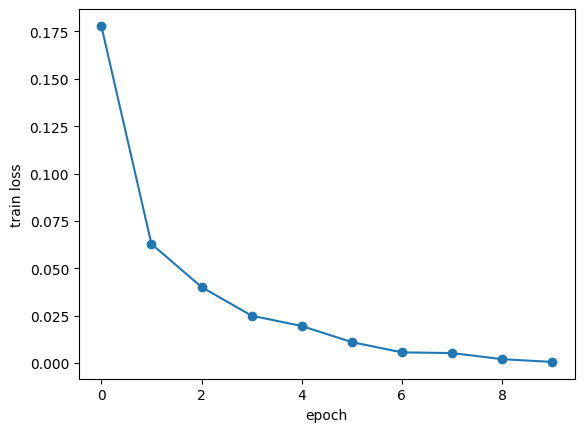

In [13]:
#Testing
model.eval()
with torch.no_grad():
    acc = (model(Xte).argmax(1) == Yte).float().mean().item() * 100
baseline = (1 - Yte.float().mean().item()) * 100        # ham
print(f"Test accuracy: {acc:.1f}%  | baseline: {baseline:.1f}%  | target: 96%")

import matplotlib.pyplot as plt
plt.plot(losses, marker="o"); plt.xlabel("epoch"); plt.ylabel("train loss"); plt.show()

In [14]:
def predict(text):
    with torch.no_grad():
        p = torch.softmax(model(torch.tensor([encode(text)])), dim=1)[0, 1].item()
    return "spam" if p > 0.5 else "ham", round(p, 3)

print(predict("WINNER!! Claim your free prize now, call 0800"))
print(predict("Are we still meeting for lunch tomorrow?"))

('spam', 1.0)
('ham', 0.0)
